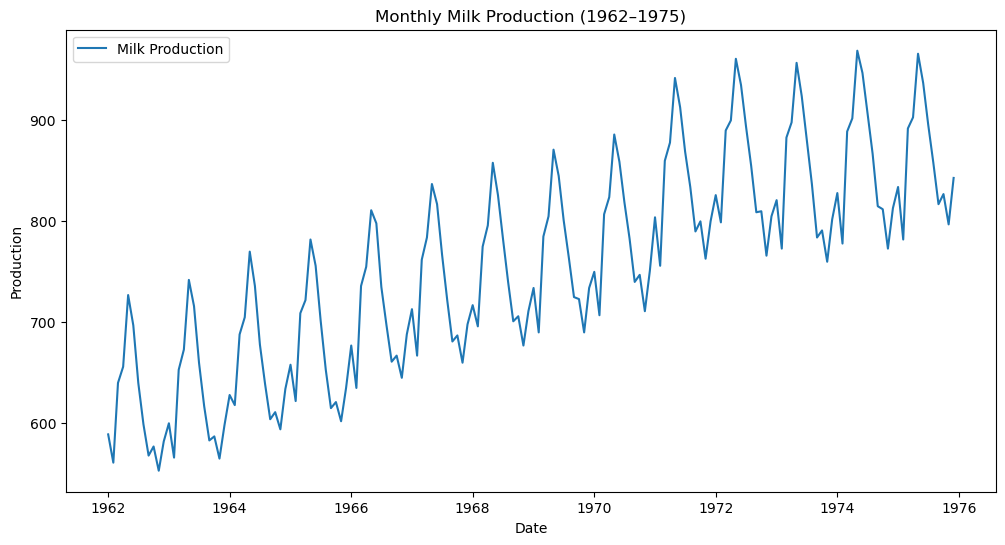

C:\Users\USER 2\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


Model Performance -> RMSE: 14.04, MAE: 11.82


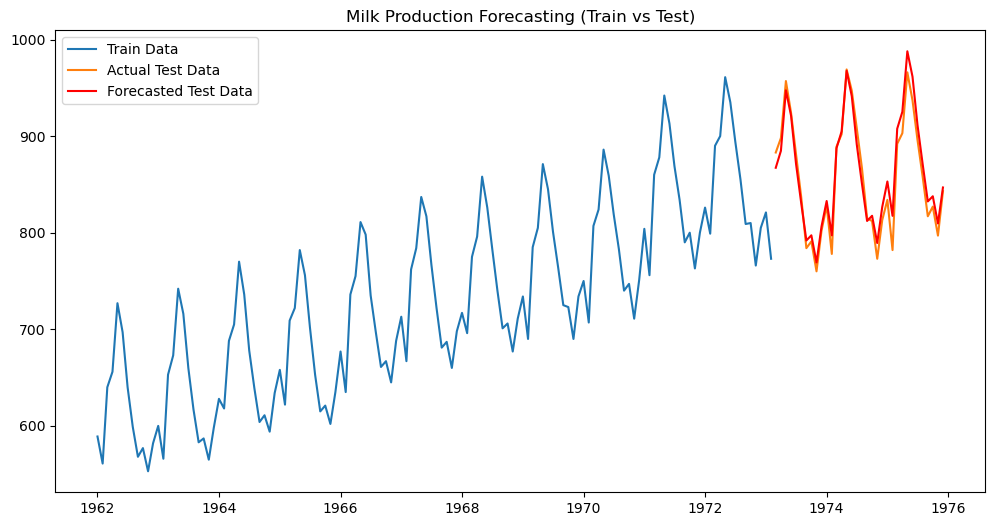

C:\Users\USER 2\AppData\Local\Temp\ipykernel_17160\2643803229.py:53: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=12, freq='M')


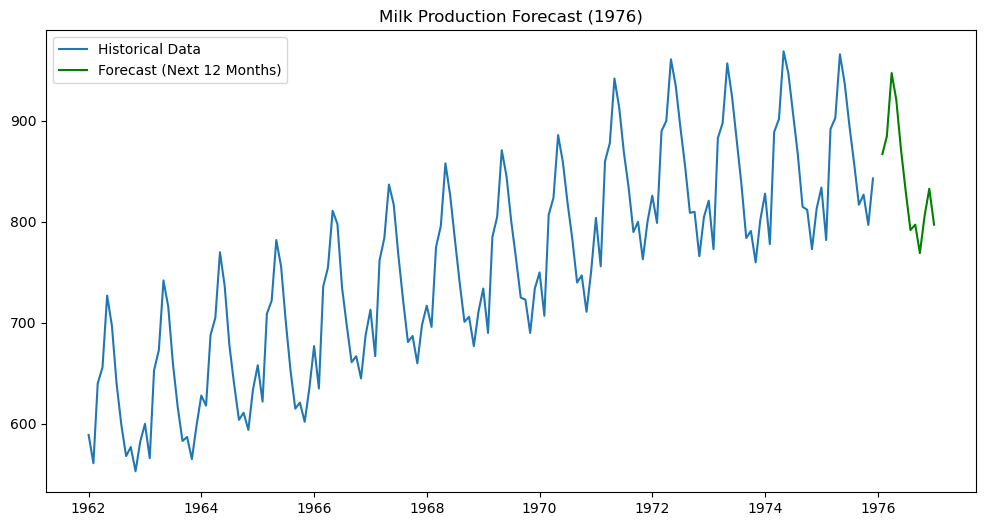

In [7]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Step 2: Load Dataset
df = pd.read_csv("C:\\Users\\USER 2\\Downloads\\monthly_milk_production.csv")
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Step 3: Exploratory Data Analysis (EDA)
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Production'], label="Milk Production")
plt.title("Monthly Milk Production (1962–1975)")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()

# Step 4: Train-Test Split
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Step 5: Build Holt-Winters Model
model = ExponentialSmoothing(train['Production'], trend="add", seasonal="add", seasonal_periods=12)
fit = model.fit()

# Step 6: Forecast on Test Set
test_forecast = fit.forecast(len(test))

# Step 7: Evaluate Performance
rmse = np.sqrt(mean_squared_error(test['Production'], test_forecast))
mae = mean_absolute_error(test['Production'], test_forecast)
print(f"Model Performance -> RMSE: {rmse:.2f}, MAE: {mae:.2f}")

# Plot Actual vs Forecast
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Production'], label="Train Data")
plt.plot(test.index, test['Production'], label="Actual Test Data")
plt.plot(test.index, test_forecast, label="Forecasted Test Data", color="red")
plt.title("Milk Production Forecasting (Train vs Test)")
plt.legend()
plt.show()

# Step 8: Forecast Next 12 Months
future_forecast = fit.forecast(12)

# Plot Future Forecast
plt.figure(figsize=(12,6))
plt.plot(df.index, df['Production'], label="Historical Data")
future_dates = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=12, freq='M')
plt.plot(future_dates, future_forecast, label="Forecast (Next 12 Months)", color="green")
plt.title("Milk Production Forecast (1976)")
plt.legend()
plt.show()